# Practice Version: Linear Classifier on Fashion-MNIST (Binary)

This notebook has only four goals:

1. Understand what real image data looks like  
2. Turn images into inputs that a linear classifier can use  
3. Train the simplest possible linear classifier  
4. Adjust a small number of parameters so that the test accuracy reaches **0.92** or higher


## Core concepts retained in this notebook

This notebook keeps the same main storyline as the original notebook:

- It is still a classification task
- It still uses a linear classifier
- It still turns continuous outputs into 0 / 1 using a **0.5** threshold
- It still looks at accuracy and the confusion matrix

To handle a real dataset, we will do the following two things:

- Normalize the images first
- Flatten the images into vectors before feeding them into the linear layer


In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from tensorflow import keras
from tensorflow.keras import layers

np.random.seed(42)
tf.random.set_seed(42)

## 1. Download and inspect the data

Here we use `Fashion-MNIST`.  
It is a classic beginner-friendly visual classification dataset.  
Instead of doing 10-class classification, we will select only two classes and turn it into a binary classification task.


In [2]:
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

print("x_train shape:", x_train.shape)
print("y_train shape:", y_train.shape)
print("x_test shape:", x_test.shape)
print("y_test shape:", y_test.shape)

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
x_train shape: (60000, 28, 28)
y_train shape: (60000,)
x_test shape: (10000, 28, 28)
y_test shape: (10000,)


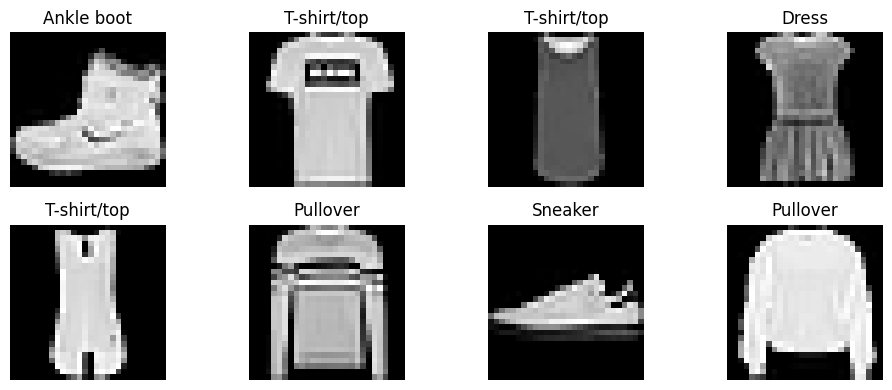

In [3]:
plt.figure(figsize=(10, 4))
for i in range(8):
    plt.subplot(2, 4, i + 1)
    plt.imshow(x_train[i], cmap="gray")
    plt.title(class_names[y_train[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

## 2. Keep only two classes and turn it into binary classification

We simplify the task into binary classification.  
Here we fix the two classes as:

- `7 = Sneaker`
- `9 = Ankle boot`

And we convert the labels to:

- Sneaker -> 0
- Ankle boot -> 1


In [4]:
keep_train = np.isin(y_train, [7, 9])
keep_test = np.isin(y_test, [7, 9])

x_train = x_train[keep_train]
y_train = y_train[keep_train]

x_test = x_test[keep_test]
y_test = y_test[keep_test]

y_train = (y_train == 9).astype("float32").reshape(-1, 1)
y_test = (y_test == 9).astype("float32").reshape(-1, 1)

print("binary x_train shape:", x_train.shape)
print("binary y_train shape:", y_train.shape)
print("binary x_test shape:", x_test.shape)
print("binary y_test shape:", y_test.shape)

binary x_train shape: (12000, 28, 28)
binary y_train shape: (12000, 1)
binary x_test shape: (2000, 28, 28)
binary y_test shape: (2000, 1)


## 3. Preprocessing: normalization + flattening

- The original pixel range is **0 to 255**
- Each image has size **28 × 28**
- A linear layer takes a vector as input, so each image needs to be flattened into one row


In [5]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

x_train = x_train.reshape(len(x_train), -1)
x_test = x_test.reshape(len(x_test), -1)

print("processed x_train shape:", x_train.shape)
print("processed x_test shape:", x_test.shape)

processed x_train shape: (12000, 784)
processed x_test shape: (2000, 784)


In [6]:
# Shuffle once before splitting validation data.
indices = np.random.permutation(len(x_train))
x_train = x_train[indices]
y_train = y_train[indices]

num_val_samples = int(0.2 * len(x_train))

x_val = x_train[:num_val_samples]
y_val = y_train[:num_val_samples]

x_train_small = x_train[num_val_samples:]
y_train_small = y_train[num_val_samples:]

print("train:", x_train_small.shape, y_train_small.shape)
print("val:  ", x_val.shape, y_val.shape)

train: (9600, 784) (9600, 1)
val:   (2400, 784) (2400, 1)


## 4. Define and train the linear classifier

Here we still use:

- One output unit
- Linear activation `linear`
- Mean squared error `mse`

Start with a relatively poor setting, then improve it gradually:

- `learning_rate`: you can start from `1e-4`, then try `1e-3` or `1e-2`
- `epochs`: `5` is often too few; you can try `50` or `100`

Goal: make **test accuracy >= 0.92**


In [7]:
learning_rate = 1e-4
epochs = 5
batch_size = 512

model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(1, activation="linear")
])

model.compile(
    optimizer=keras.optimizers.SGD(learning_rate=learning_rate),
    loss="mse",
    metrics=["accuracy"]
)

history = model.fit(
    x_train_small,
    y_train_small,
    epochs=epochs,
    batch_size=batch_size,
    validation_data=(x_val, y_val),
    shuffle=True,
    verbose=1
)

Epoch 1/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.6676 - loss: 0.2420 - val_accuracy: 0.7108 - val_loss: 0.2110
Epoch 2/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7377 - loss: 0.1919 - val_accuracy: 0.7588 - val_loss: 0.1766
Epoch 3/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7774 - loss: 0.1665 - val_accuracy: 0.7887 - val_loss: 0.1586
Epoch 4/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8011 - loss: 0.1530 - val_accuracy: 0.8104 - val_loss: 0.1486
Epoch 5/5
19/19 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8175 - loss: 0.1451 - val_accuracy: 0.8225 - val_loss: 0.1424


## 5. Observe the training process

First look at how the training and validation accuracies change.  
If the validation accuracy stays very low, check these first:

1. Is the learning rate too small?  
2. Are there too few epochs?


In [ ]:
history_dict = history.history

trn_acc_values = history_dict["accuracy"]
val_acc_values = history_dict["val_accuracy"]
epoch_range = range(1, len(trn_acc_values) + 1)

plt.plot(epoch_range, trn_acc_values, "bo", label="Training accuracy")
plt.plot(epoch_range, val_acc_values, "b", label="Validation accuracy")
plt.title("Training and Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

print("Best validation accuracy:", np.max(val_acc_values))

## 6. Make predictions on the validation set

Here we continue to follow the idea from the original notebook:  
first get the continuous outputs, then use **0.5** as the threshold to convert them into class labels.


In [ ]:
val_predictions = model.predict(x_val, verbose=0)
val_pred_classes = (val_predictions > 0.5)

val_confusion = pd.DataFrame({
    "Predicted": val_pred_classes[:, 0],
    "Actual": y_val[:, 0].astype(bool)
})

print("Validation confusion matrix:")
print(pd.crosstab(val_confusion["Predicted"], val_confusion["Actual"]))

## 7. Final evaluation on the test set

Notes:

- The validation set is used for tuning parameters
- The test set is used only for the final report

After you have tuned the validation accuracy above the target threshold, then look at the test result.


In [ ]:
test_predictions = model.predict(x_test, verbose=0)
test_pred_classes = (test_predictions > 0.5)

test_accuracy = np.mean(test_pred_classes == y_test)
print("Test accuracy:", test_accuracy)

test_confusion = pd.DataFrame({
    "Predicted": test_pred_classes[:, 0],
    "Actual": y_test[:, 0].astype(bool)
})

print("\nTest confusion matrix:")
print(pd.crosstab(test_confusion["Predicted"], test_confusion["Actual"]))